
# <span style="color:rgb(213,80,0)">Example using generic control input with cycles</span>

We use a generic control input, as described in [json schema documentation](https://github.com/BattMoTeam/BattMo/blob/main/Utilities/JsonSchemas/GenericControl.schema.json).

## Input setup

We load material parameter input parameters


In [1]:
jsonstruct_material = parseBattmoJson(fullfile('ParameterData'        , ...
                                               'BatteryCellParameters', ...
                                               'LithiumIonBatteryCell', ...
                                               'lithium_ion_battery_nmc_graphite.json'));


We load geometry parameter input parameters


In [2]:
jsonstruct_geometry = parseBattmoJson(fullfile('Examples', 'JsonDataFiles', 'geometryChen.json'));


We load the generic control parameter we want to use


In [3]:
jsonstruct_control  = parseBattmoJson(fullfile('Examples', 'JsonDataFiles', 'generic_step_control_cycle_example.json'));


We print it to command window


In [4]:
viewJsonStruct(jsonstruct_control)

{
  "Control": {
    "controlPolicy": "Generic",
    "controlsteps": [
      {
        "controltype": "cycle",
        "numberOfcycles": 3,
        "cycleControlSteps": [
          {
            "controltype": "current",
            "value": 5,
            "direction": "discharge",
            "termination": {
              "quantity": "voltage",
              "value": 3,
              "comparison": "below"
            },
            "timeStepSize": 100
          },
          {
            "controltype": "voltage",
            "value": 3,
            "termination": {
              "quantity": "current",
              "value": 0.0001,
              "comparison": "absolute value below"
            },
            "timeStepSize": 100
          },
          {
            "controltype": "current",
            "value": 5,
            "direction": "charge",
            "termination": {
              "quantity": "voltage",
              "value": 4,
              "comparison": "above"
          


We remove the fields that are not relevant for this example. This is done to simplify the input parameters and focus on the relevant aspects of the model.


In [5]:
jsonstruct_material = removeJsonStructFields(jsonstruct_material              , ...
                                             {'Control', 'DRate'}             , ...
                                             {'Control', 'controlPolicy'}     , ...
                                             {'Control', 'upperCutoffVoltage'}, ...
                                             {'Control', 'rampupTime'}        , ...
                                             {'Control', 'lowerCutoffVoltage'});


We merge all the input structures


In [6]:
jsonstruct = mergeJsonStructs({jsonstruct_material, ...
                               jsonstruct_geometry, ...
                               jsonstruct_control});


We do not include thermal effects and the current collectors in this example to simplify the model.


In [7]:
jsonstruct.use_thermal                = false;
jsonstruct.include_current_collectors = false;

output = runBatteryJson(jsonstruct);

## Plotting


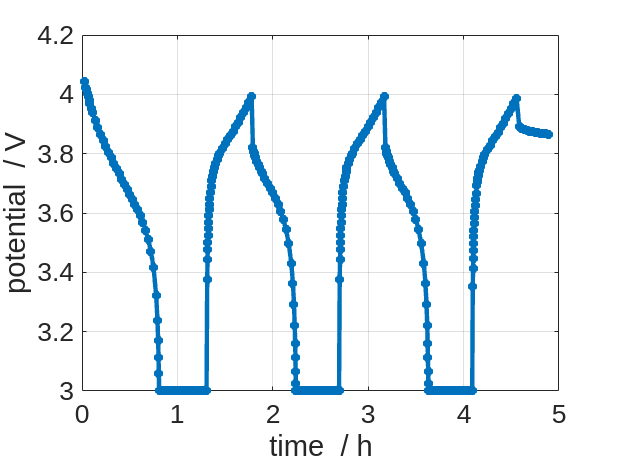

In [8]:
states = output.states;

E = cellfun(@(x) x.Control.E, states);
I = cellfun(@(x) x.Control.I, states);
time = cellfun(@(x) x.time, states);

figure
plot(time/hour, E, '*-', 'linewidth', 3);
grid on
xlabel 'time  / h';
ylabel 'potential  / V';


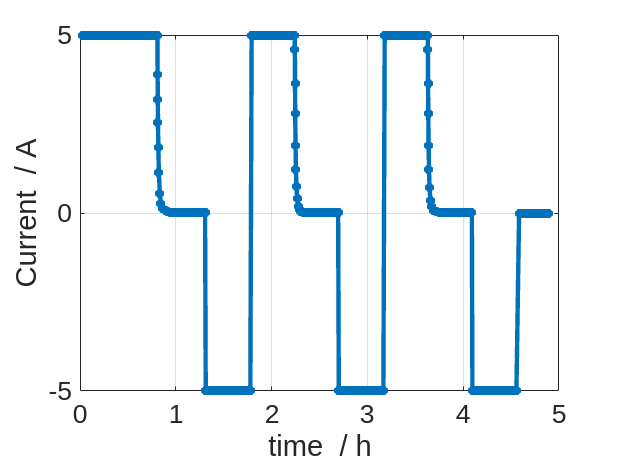

In [9]:

figure
plot(time/hour, I, '*-', 'linewidth', 3);
grid on
xlabel 'time  / h';
ylabel 'Current  / A';